In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from SALib.analyze import delta,pawn
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import scipy.stats

pd.set_option('future.no_silent_downcasting', True)

In [56]:
sheet_location = "C:\\Users\\konstantinos.kanavou\\OneDrive - University of Luxembourg\\Taskov.xlsx"
df_input = pd.read_excel(sheet_location, sheet_name=["ChipSat-1 Trade", "AI4Space Trade", "POQUITO Trade", "ChiPySat Trade"])
# Append project number to each dataframe
for i, df in enumerate(df_input.values()):
    df["Project"] = i + 1
df_input = pd.concat(df_input.values(), ignore_index=True)

risk_map = { "Lower": -1, "Base": 0, "Higher": 1 }
df_input.replace({"Risk": risk_map}, inplace=True)

df_input

,CF #,Name,Applied,Cost,Time,Risk,Project
0,0,Baseline,NaN,8930,478,0,1
1,1,Bypassing structural/thermal analysis,Y,1390,-180,1,1
2,2,Soldering PCBs in-house,N,-2000,72,-1,1
3,3,Multi-step development,Y,1720,-120,-1,1
4,4,Short iterations,Y,695,-120,1,1
5,5,Iterating over partitions,Y,-1840,-50,1,1
6,6,Robust software framework,N,0,40,-1,1
7,0,Baseline,NaN,4900,468,0,2
8,1,Bypassing structural/thermal analysis,Y,0,-180,1,2
9,2,Soldering PCBs in-house,N,-1300,24,0,2


In [123]:
# Calculate relative value estimations for each treatment, for each project

relative_map = { 
    "Time": True,
    "Cost": True,
    "Risk": False
}

df = df_input.copy()

# Convert relative map columns with True to float64
df = df.astype({key: np.float64 for key, relative in relative_map.items() if relative})

for project in df["Project"].unique():
    project_mask = df["Project"] == project
    df_project = df[project_mask]
    baseline = df_project[df_project["CF #"] == 0]
    
    for key, relative in relative_map.items():
        baseline_value = baseline[key].iloc[0]

        if relative:
            not_applied_mask = project_mask & (df["Applied"] == "N")
            df.loc[not_applied_mask, key] = 1.0 + df.loc[not_applied_mask, key] / baseline_value

            applied_mask = project_mask & (df["Applied"] == "Y")
            df.loc[applied_mask, key] = baseline_value / (baseline_value - df.loc[applied_mask, key])
        else:
            not_applied_mask = project_mask & (df["Applied"] == "N")
            df.loc[not_applied_mask, key] = baseline_value + df.loc[not_applied_mask, key]

            applied_mask = project_mask & (df["Applied"] == "Y")
            df.loc[applied_mask, key] = baseline_value - df.loc[applied_mask, key]


for key, relative in relative_map.items():
    if relative:
        df.loc[df["Applied"].isna(), key] = 1

df

,CF #,Name,Applied,Cost,Time,Risk,Project
0,0,Baseline,NaN,1.000000,1.000000,0,1
1,1,Bypassing structural/thermal analysis,Y,1.184350,0.726444,-1,1
2,2,Soldering PCBs in-house,N,0.776036,1.150628,-1,1
3,3,Multi-step development,Y,1.238558,0.799331,1,1
4,4,Short iterations,Y,1.084396,0.799331,-1,1
5,5,Iterating over partitions,Y,0.829155,0.905303,-1,1
6,6,Robust software framework,N,1.000000,1.083682,-1,1
7,0,Baseline,NaN,1.000000,1.000000,0,2
8,1,Bypassing structural/thermal analysis,Y,1.000000,0.722222,-1,2
9,2,Soldering PCBs in-house,N,0.734694,1.051282,0,2


1.0
0.02857142857142857
0.02857142857142857
0.02857142857142857
0.6285714285714286
0.6285714285714286
1.0
0.6285714285714286
1.0
0.6857142857142857
0.02857142857142857
0.34285714285714286
0.05714285714285714
0.22857142857142856
1.0
1.0
1.0
0.02857142857142857
0.6857142857142857
0.6857142857142857
0.22857142857142856
0.6285714285714286
0.6285714285714286
0.6285714285714286


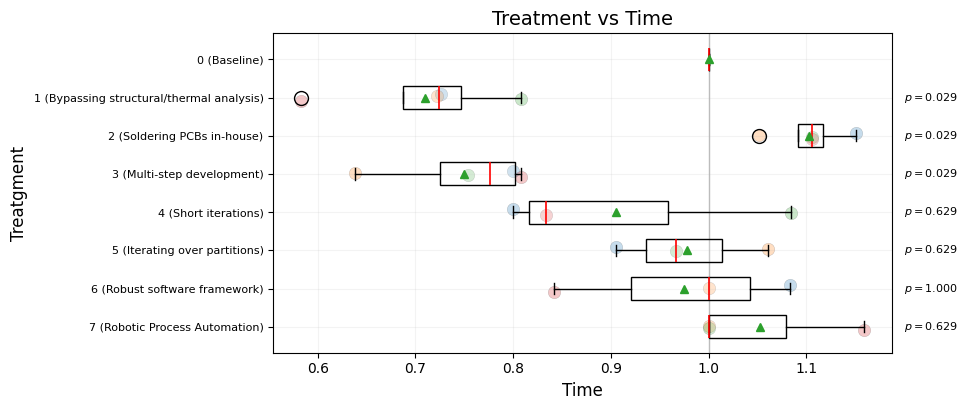

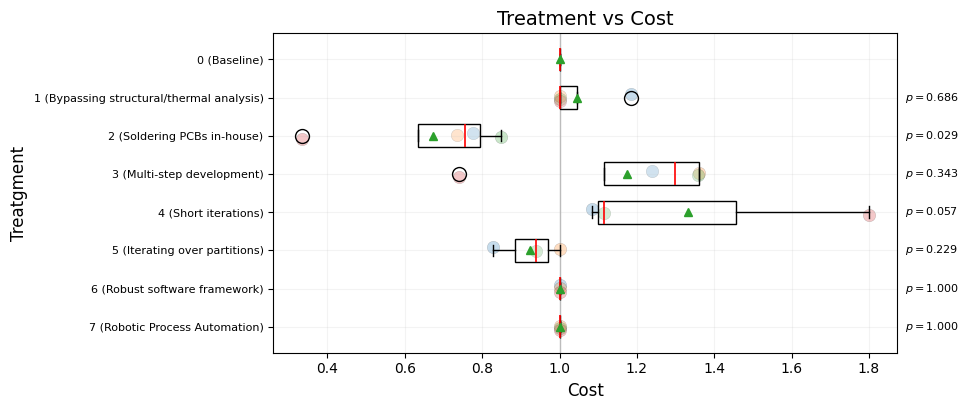

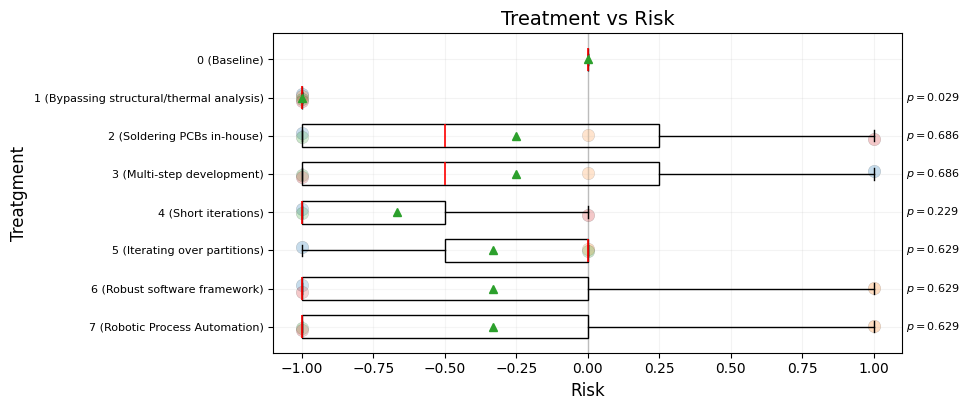

In [14]:
projects = df["Project"].unique()
project_list = [ "ChipSat-1", "AI4Space", "POQUITO", "ChiPySat" ]
cmap = plt.get_cmap('tab10')
colors = {project: cmap(i) for i, project in enumerate(projects)}

for parameter in relative_map.keys():
    treatments = np.sort(df['CF #'].unique())
    treatment_labels = ["{} ({})".format(t, df.loc[df['CF #'] == t, 'Name'].iloc[0]) for t in treatments]

    data_by_t = [df.loc[df['CF #'] == t, parameter].values for t in treatments]

    fig, ax = plt.subplots(figsize=(14 * 0.7, 6 * 0.7))

    # base line
    ax.axvline(x=df.loc[df['CF #'] == 0, parameter].iloc[0], color='gray', alpha=0.5, linestyle='-', linewidth=1.0, zorder=-1)

    # scatter background: jitter points and color by project
    rng = np.random.default_rng(0)
    for proj in projects:
        proj_mask = (df['Project'] == proj) & (df['CF #'] != 0)
        xs = df.loc[proj_mask, 'CF #'].values
        ys = df.loc[proj_mask, parameter].values
        if len(xs):
            jitter = (proj - (len(projects) + 1) / 2) * (0.16 / (len(projects) - 1))
            xs, ys = ys, xs + jitter
            ax.scatter(xs, ys, color=colors.get(proj, 'gray'), alpha=0.25, s=80, edgecolors='k', linewidths=0.3, zorder=1)

    bp = ax.boxplot(data_by_t, positions=treatments, widths=0.6, patch_artist=True, notch=False, manage_ticks=False, zorder=2, showmeans=True, orientation='horizontal')
    # style boxes to be transparent so background points remain visible
    for box in bp['boxes']:
        box.set(facecolor=(1, 1, 1, 0.2), edgecolor='black', linewidth=1.0)
    # for whisker in bp['whiskers']:
    #     whisker.set(color='black', linewidth=0.8)
    # for cap in bp['caps']:
    #     cap.set(color='black', linewidth=0.8)
    for median in bp['medians']:
        median.set(color='red', linewidth=1.2)
    for flier in bp['fliers']:
        flier.set(marker='o', color='black', alpha=1, linewidth=1, ms=10)

    # statistics
    for t in treatments:
        b = df.loc[df['CF #'] == 0, parameter].astype(np.float64)
        x = df.loc[df['CF #'] == t, parameter].astype(np.float64)
        statistics = scipy.stats.mannwhitneyu(b, x, alternative='two-sided', method='exact')
        print(statistics.pvalue)

        # Stick p-value on the right side of the plot
        y_pos = t
        x_pos = ax.get_xlim()[1] * 1.01
        if t != 0:
            ax.text(x_pos, y_pos, f'$p={statistics.pvalue:.3f}$', fontsize=8, verticalalignment='center', horizontalalignment='left')

    ax.set_ylabel('Treatgment', fontsize=12)
    ax.set_xlabel(parameter, fontsize=12)
    ax.set_title(f'Treatment vs {parameter}', fontsize=14)
    ax.set_yticks(treatments)
    ax.set_yticklabels(treatment_labels, fontsize=8)
    # ax.tick_params( axis='y', which='major', length=15 )
    ax.yaxis.set_inverted(True)
    ax.grid(True, alpha=0.15)

    # legend for projects
    handles = [mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[p], markersize=8, label=project_list[p - 1]) for p in projects]
    #ax.legend(handles=handles, title='Project', bbox_to_anchor=(0.5, -0.5), loc='lower center', fontsize=8, ncol=4)
    #ax.legend(handles=handles, title='Project', bbox_to_anchor=(1,0.5), loc='center left', fontsize=8, ncol=1)

    plt.tight_layout()



    # plt.figure(figsize=(10, 6))
    # for project in df["Project"].unique():
    #     project_mask = df["Project"] == project
    #     df_project = df[project_mask]
    #     plt.scatter(df_project["CF #"], df_project[parameter], label=f"Project {project}")
    
    # plt.title(f"{parameter} Relative Estimations Across Projects")
    # plt.xlabel("CF #")
    # plt.ylabel(f"{parameter} Relative Estimation")
    # plt.legend()
    # plt.grid(True)
    # plt.show()